# 03 — FOV46 preprocessing + Leiden sweep (interactive)

This notebook explicitly reads a **saved QC variant from Notebook 02** using `QC_TAG`, rebuilds the normalized expression graph, runs Leiden resolutions 0.1–1.0, and supports interactive marker/spatial inspection.

No automatic “best” resolution is selected. Different graph experiments are stored under versioned `LEIDEN_TAG` directories and are not allowed to silently overwrite each other.


In [11]:
# ============================================================
# Dataset_02 CosMx — Jupyter initialization
# ============================================================

from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc


# ------------------------------------------------------------
# Robustly locate project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """
    Search current directory and its parents for the project root.

    A valid project root contains:
        src/
        data/
    """

    for candidate in [start, *start.parents]:

        if (
            (candidate / "src").is_dir()
            and
            (candidate / "data").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate project root.\n"
        f"Starting directory: {start}\n\n"
        "Expected a parent directory containing:\n"
        "  src/\n"
        "  data/"
    )


PROJECT_ROOT = find_project_root(CURRENT_DIR)


# ------------------------------------------------------------
# Make src importable
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


# ------------------------------------------------------------
# Common paths
# ------------------------------------------------------------

RAW_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

SPATIAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "spatial"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "config"
)


# ------------------------------------------------------------
# Scanpy settings
# ------------------------------------------------------------

sc.settings.verbosity = 2


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)

print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)

print()

print(
    "src exists         :",
    (PROJECT_ROOT / "src").exists(),
)

print(
    "raw data exists    :",
    RAW_DIR.exists(),
)

print(
    "processed exists   :",
    PROCESSED_DIR.exists(),
)

print(
    "spatial exists     :",
    SPATIAL_DIR.exists(),
)

Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python

src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [12]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from config.markers import MARKER_PANEL

# ============================================================
# INPUT QC VARIANT — EDIT HERE
# Must match QC_TAG saved by Notebook 02.
# ============================================================
QC_TAG = "mad3_interactive"

QC_INPUT_DIR = RESULTS_DIR / "FOV46" / "qc_variants" / QC_TAG
QC_INPUT = QC_INPUT_DIR / f"GSM9046088_FOV46_qc_filtered_{QC_TAG}.h5ad"
QC_THRESHOLDS_FILE = QC_INPUT_DIR / f"qc_thresholds_{QC_TAG}.json"

print("=" * 70)
print("LEIDEN INPUT")
print("=" * 70)
print("QC_TAG           :", QC_TAG)
print("QC input         :", QC_INPUT)
print("Input exists     :", QC_INPUT.exists())
print("Thresholds file  :", QC_THRESHOLDS_FILE)
print("Thresholds exists:", QC_THRESHOLDS_FILE.exists())

if not QC_INPUT.exists():
    raise FileNotFoundError(
        f"QC input not found:\n{QC_INPUT}\n\n"
        "Return to Notebook 02, set SAVE_QC=True, and save the desired QC variant first."
    )

a = sc.read_h5ad(QC_INPUT)
print("\nLoaded QC-filtered object:")
print(a)

if QC_THRESHOLDS_FILE.exists():
    saved_qc = json.loads(QC_THRESHOLDS_FILE.read_text())
    print("\nQC thresholds used for this input:")
    display(saved_qc)


LEIDEN INPUT
QC_TAG           : mad3_interactive
QC input         : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Input exists     : True
Thresholds file  : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/qc_thresholds_mad3_interactive.json
Thresholds exists: True

Loaded QC-filtered object:
AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts',

{'min_counts': 75,
 'min_genes': 32,
 'max_counts': 2400,
 'max_control_fraction': 0.007182337045669567,
 'min_cell_area': 3337.0824715846375,
 'max_cell_area': 14913.890936282127}

In [13]:
# ============================================================
# EDITABLE graph / Leiden parameters
# ============================================================
N_PCS = 30
N_NEIGHBORS = 15
SEED = 42
RESOLUTIONS = np.round(np.arange(0.1, 1.01, 0.1), 1).tolist()

# A descriptive tag prevents different graph experiments from overwriting each other.
LEIDEN_TAG = f"{QC_TAG}_pcs{N_PCS}_nn{N_NEIGHBORS}"

print("LEIDEN_TAG :", LEIDEN_TAG)
print("N_PCS      :", N_PCS)
print("N_NEIGHBORS:", N_NEIGHBORS)
print("SEED       :", SEED)
print("RESOLUTIONS:", RESOLUTIONS)

# Recreate analysis object from raw biological counts each time this cell is run.
b = a.copy()
if "counts" not in b.layers:
    raise KeyError("Expected raw biological counts in b.layers['counts'].")

b.X = b.layers["counts"].copy()
sc.pp.normalize_total(b, target_sum=1e4)
sc.pp.log1p(b)
b.raw = b.copy()
sc.pp.scale(b, max_value=10)

npcs = min(N_PCS, b.n_obs - 1, b.n_vars - 1)
sc.tl.pca(b, n_comps=npcs, svd_solver="arpack", random_state=SEED)
sc.pp.neighbors(b, n_neighbors=N_NEIGHBORS, n_pcs=npcs, random_state=SEED)
sc.tl.umap(b, random_state=SEED)

rows = []
for r in RESOLUTIONS:
    key = f"leiden_r{r:g}"
    sc.tl.leiden(b, resolution=r, key_added=key, random_state=SEED)
    vc = b.obs[key].value_counts()
    rows.append({
        "resolution": r,
        "key": key,
        "n_clusters": len(vc),
        "min_cluster_size": int(vc.min()),
        "median_cluster_size": float(vc.median()),
        "tiny_cluster_fraction": float(vc[vc < max(10, int(0.01*b.n_obs))].sum() / b.n_obs),
    })

summary = pd.DataFrame(rows)
summary["ARI_vs_previous"] = np.nan
summary["NMI_vs_previous"] = np.nan
for i in range(1, len(summary)):
    prev = summary.loc[i-1, "key"]
    cur = summary.loc[i, "key"]
    summary.loc[i, "ARI_vs_previous"] = adjusted_rand_score(b.obs[prev], b.obs[cur])
    summary.loc[i, "NMI_vs_previous"] = normalized_mutual_info_score(b.obs[prev], b.obs[cur])

display(summary)


LEIDEN_TAG : mad3_interactive_pcs30_nn15
N_PCS      : 30
N_NEIGHBORS: 15
SEED       : 42
RESOLUTIONS: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=30


/home/jqu/.conda/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)


,resolution,key,n_clusters,min_cluster_size,median_cluster_size,tiny_cluster_fraction,ARI_vs_previous,NMI_vs_previous
0,0.1,leiden_r0.1,2,139,469.0,0.0,NaN,NaN
1,0.2,leiden_r0.2,2,139,469.0,0.0,1.000000,1.000000
2,0.3,leiden_r0.3,3,140,155.0,0.0,0.533389,0.656016
3,0.4,leiden_r0.4,4,141,236.0,0.0,0.522606,0.741081
4,0.5,leiden_r0.5,4,142,186.0,0.0,0.683548,0.782406
5,0.6,leiden_r0.6,6,17,139.0,0.0,0.837224,0.843635
6,0.7,leiden_r0.7,7,15,135.0,0.0,0.746349,0.836233
7,0.8,leiden_r0.8,7,15,141.0,0.0,0.779207,0.847736
8,0.9,leiden_r0.9,7,18,140.0,0.0,0.863850,0.894069
9,1.0,leiden_r1,8,19,127.0,0.0,0.785301,0.844922


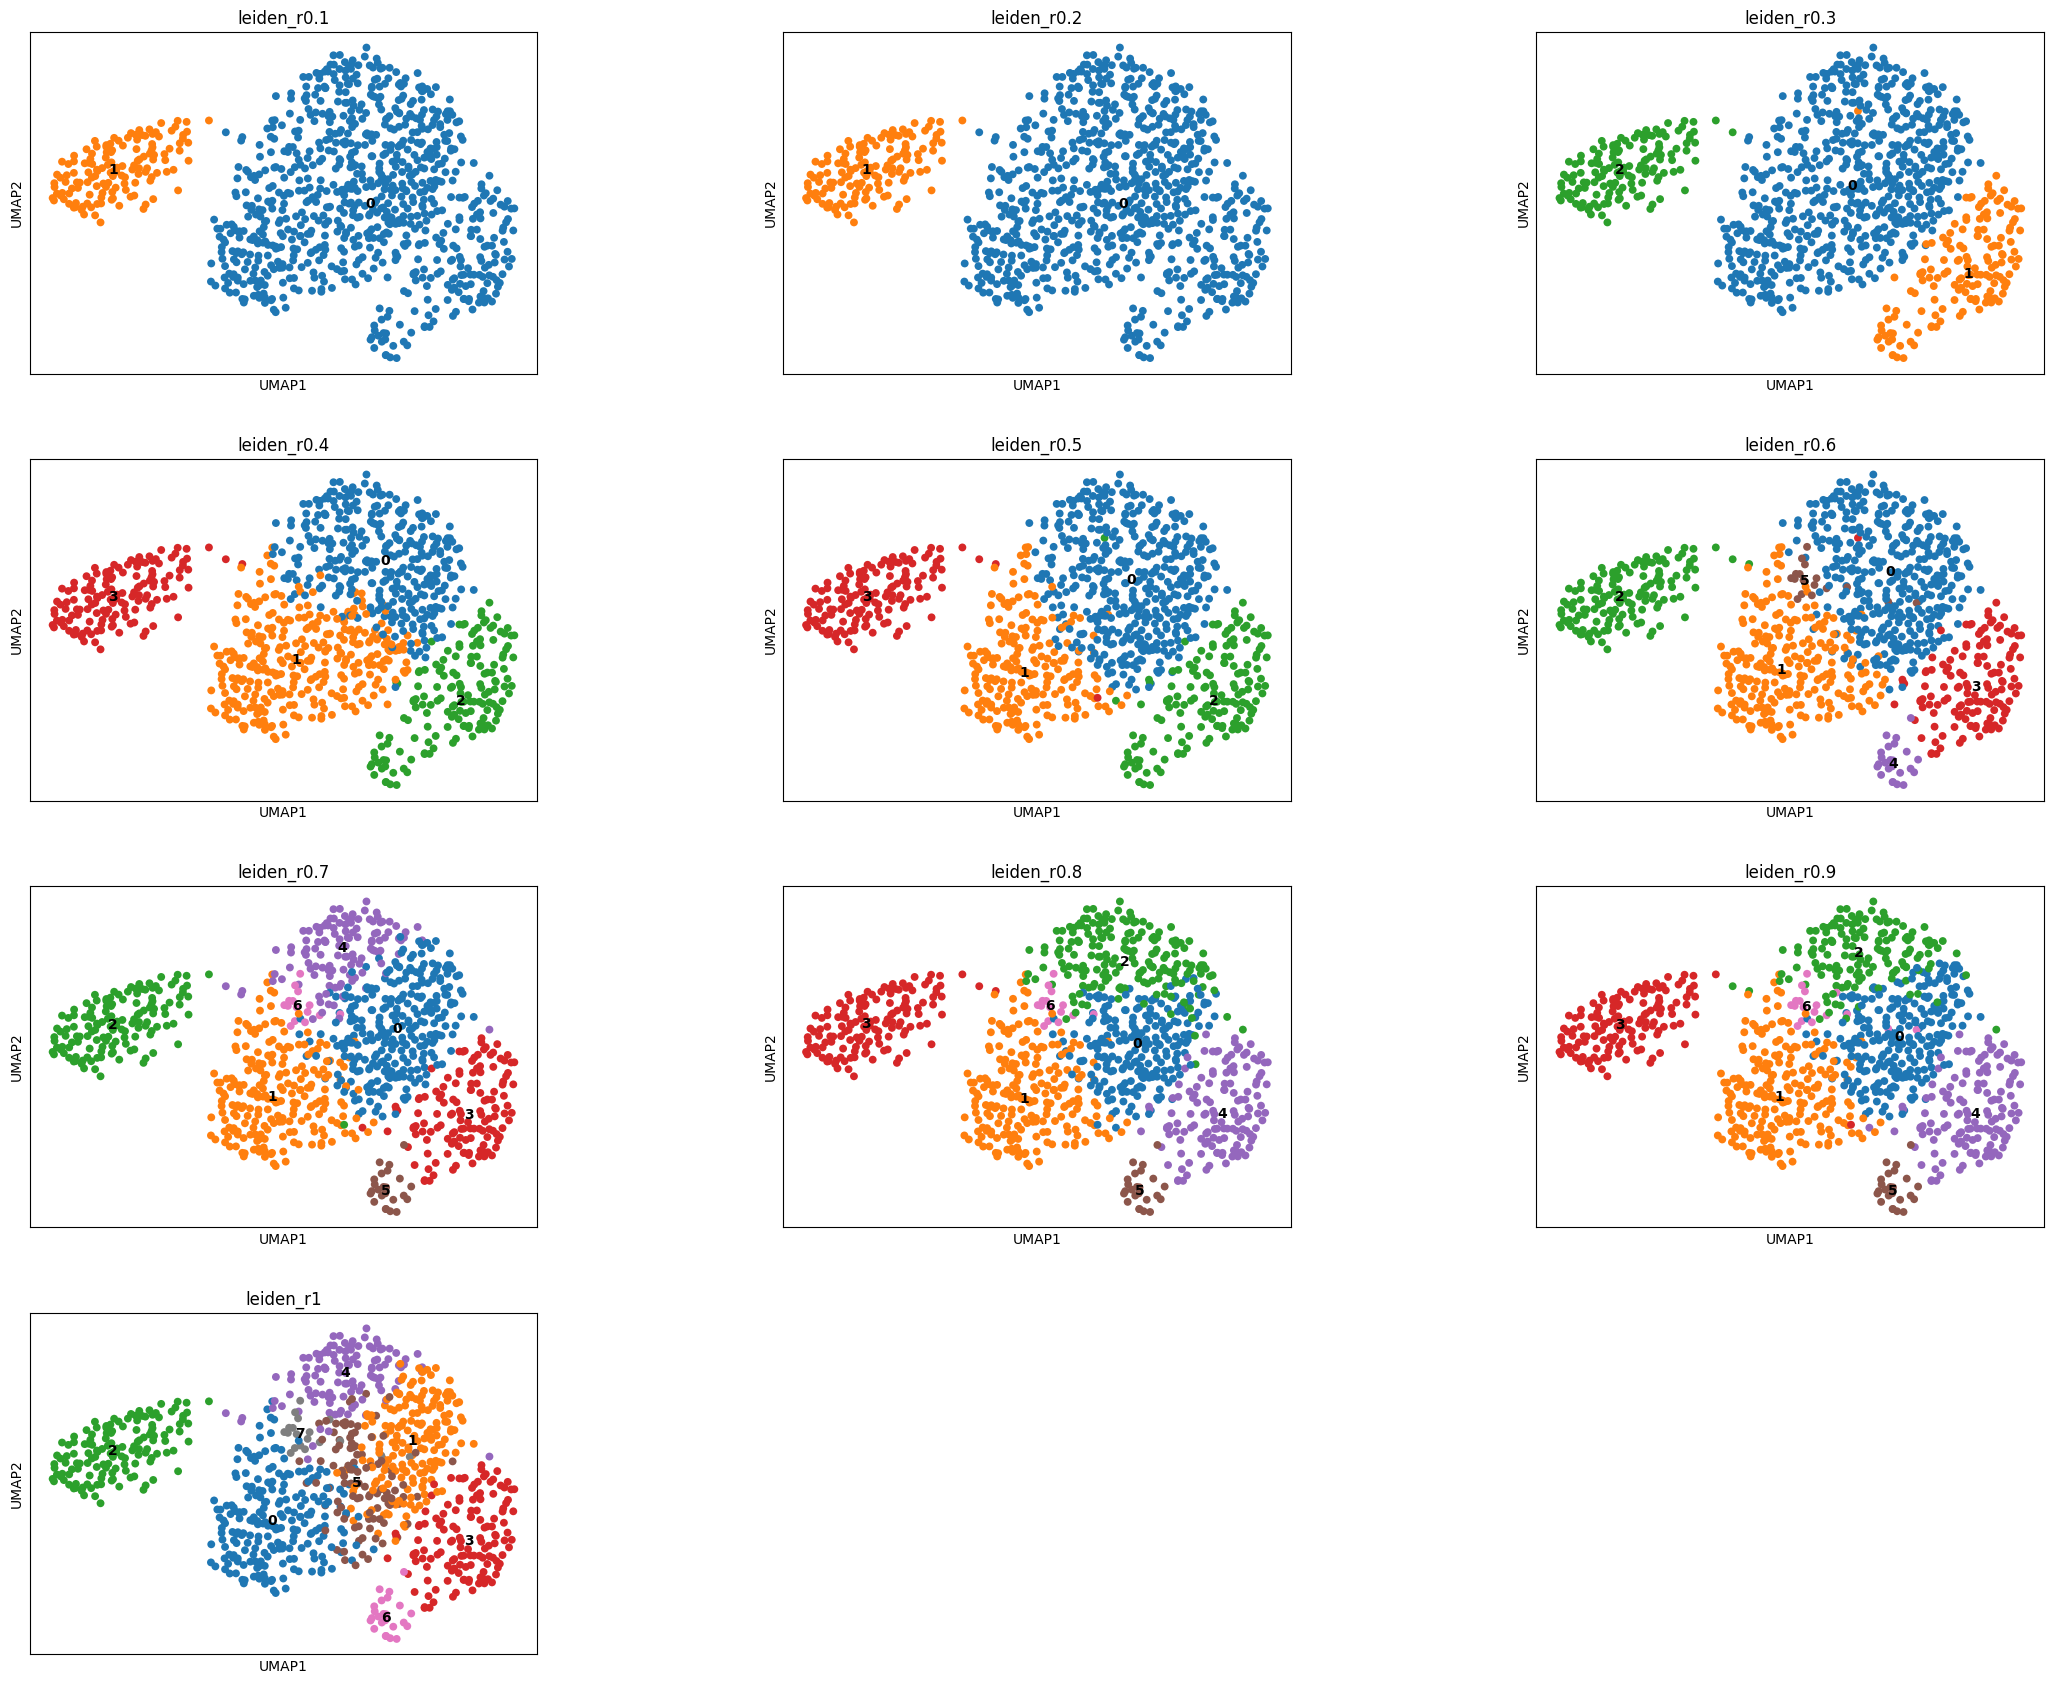

In [14]:
# UMAP sweep — same embedding, different Leiden labels.
keys = summary["key"].tolist()
sc.pl.umap(
    b,
    color=keys,
    ncols=3,
    frameon=True,
    wspace=.35,
    legend_loc="on data",
)


In [15]:
# Inspect transition table between any two resolutions.
# Change these values and rerun only this cell.
R_FROM = 0.5
R_TO = 0.6

key_from = f"leiden_r{R_FROM:g}"
key_to = f"leiden_r{R_TO:g}"

transition_counts = pd.crosstab(b.obs[key_from], b.obs[key_to])
transition_fraction = pd.crosstab(
    b.obs[key_from], b.obs[key_to], normalize="index"
)

print(f"Counts: {key_from} -> {key_to}")
display(transition_counts)
print(f"Row fractions: {key_from} -> {key_to}")
display(transition_fraction.style.format("{:.2f}"))


Counts: leiden_r0.5 -> leiden_r0.6


leiden_r0.6,0,1,2,3,4,5
leiden_r0.5,,,,,,
0,376,27,0,4,0,17
1,0,213,0,0,0,0
2,1,1,0,133,24,0
3,0,1,141,0,0,0


Row fractions: leiden_r0.5 -> leiden_r0.6


leiden_r0.6,0,1,2,3,4,5
leiden_r0.5,,,,,,
0,0.89,0.06,0.00,0.01,0.00,0.04
1,0.00,1.00,0.00,0.00,0.00,0.00
2,0.01,0.01,0.00,0.84,0.15,0.00
3,0.00,0.01,0.99,0.00,0.00,0.00


## Marker-panel inspection for one candidate resolution
Change `INSPECT_RESOLUTION` repeatedly (e.g. 0.4, 0.5, 0.6, 0.7, 0.8).

Inspecting: leiden_r0.6
leiden_r0.6
0    377
1    242
2    141
3    137
4     24
5     17
Name: count, dtype: int64
    using 'X_pca' with n_pcs = 30
Storing dendrogram info using `.uns['dendrogram_leiden_r0.6']`
categories: 0, 1, 2, etc.
var_group_labels: Epithelial, AT1, Tumor_epithelial, etc.


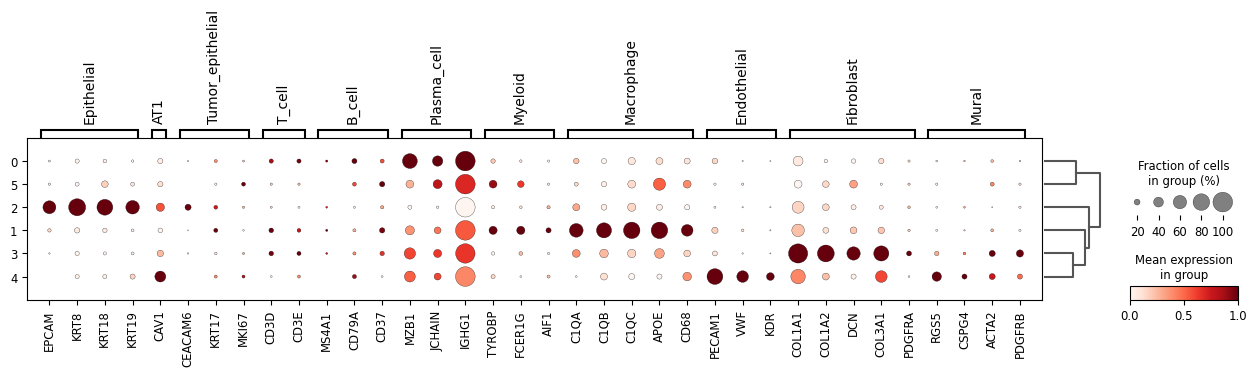

In [16]:
INSPECT_RESOLUTION = 0.6
key = f"leiden_r{INSPECT_RESOLUTION:g}"

if key not in b.obs:
    raise KeyError(f"{key} not found. Available: {[x for x in b.obs if x.startswith('leiden_r')]}")

present = {
    ct: [g for g in genes if g in b.raw.var_names]
    for ct, genes in MARKER_PANEL.items()
}
present = {ct: genes for ct, genes in present.items() if genes}

print("Inspecting:", key)
print(b.obs[key].value_counts().sort_index())

sc.pl.dotplot(
    b, present, groupby=key, use_raw=True,
    standard_scale="var", dendrogram=True
)


ranking genes
    finished (0:00:00)


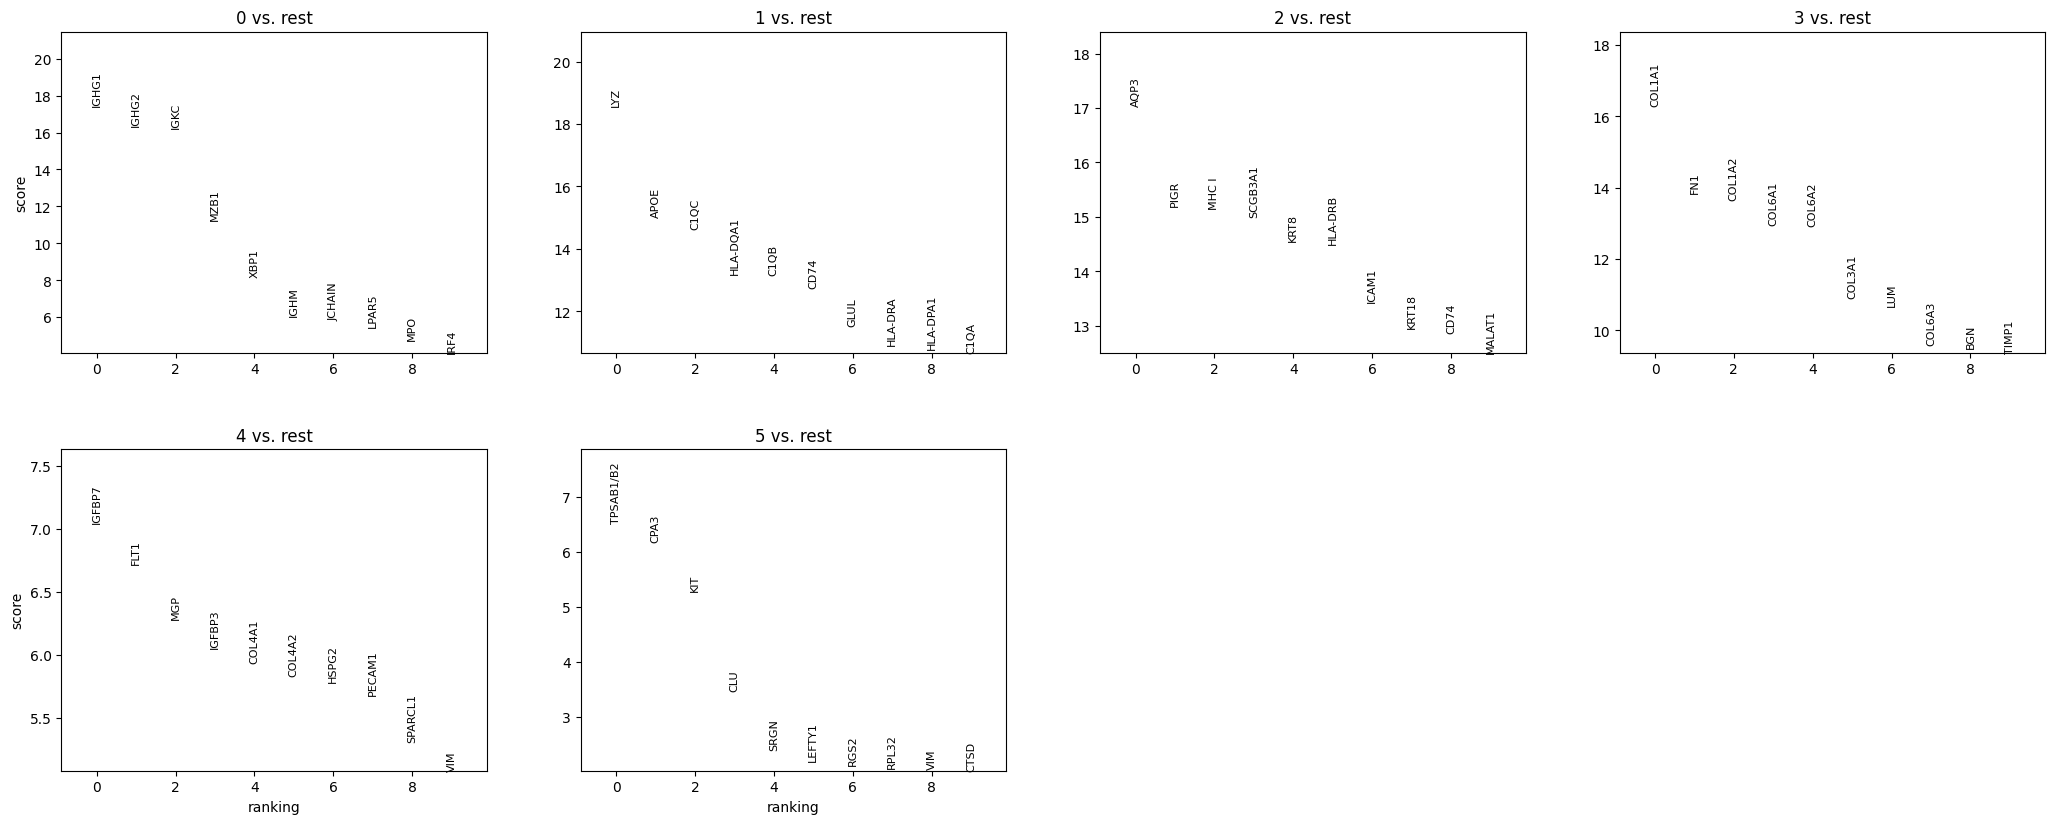

,cluster,names,scores,logfoldchanges,pvals_adj
0,0,IGHG1,17.453619,1.673616,3.231004e-65
1,0,IGHG2,16.342541,2.153990,1.638678e-57
2,0,IGKC,16.257982,1.219864,4.902300e-57
3,0,MZB1,11.245230,2.732463,2.222353e-27
4,0,XBP1,8.186818,1.462670,1.166184e-14
5,0,IGHM,6.062129,1.609525,2.633941e-08
6,0,JCHAIN,5.842372,1.835156,9.028536e-08
7,0,LPAR5,5.471440,1.644501,6.662602e-07
8,0,MPO,4.761653,1.573225,2.258982e-05
9,0,IRF4,4.062437,1.489082,4.335992e-04


In [17]:
# Cluster-vs-rest top genes for the currently inspected resolution.
rank_key = f"rank_{key}"
sc.tl.rank_genes_groups(
    b, groupby=key, method="wilcoxon", use_raw=True, key_added=rank_key
)
sc.pl.rank_genes_groups(b, key=rank_key, n_genes=10, sharey=False)

top = pd.concat([
    sc.get.rank_genes_groups_df(b, group=g, key=rank_key)
      .head(10)
      .assign(cluster=g)
    for g in b.obs[key].cat.categories
])

display(top[["cluster", "names", "scores", "logfoldchanges", "pvals_adj"]])


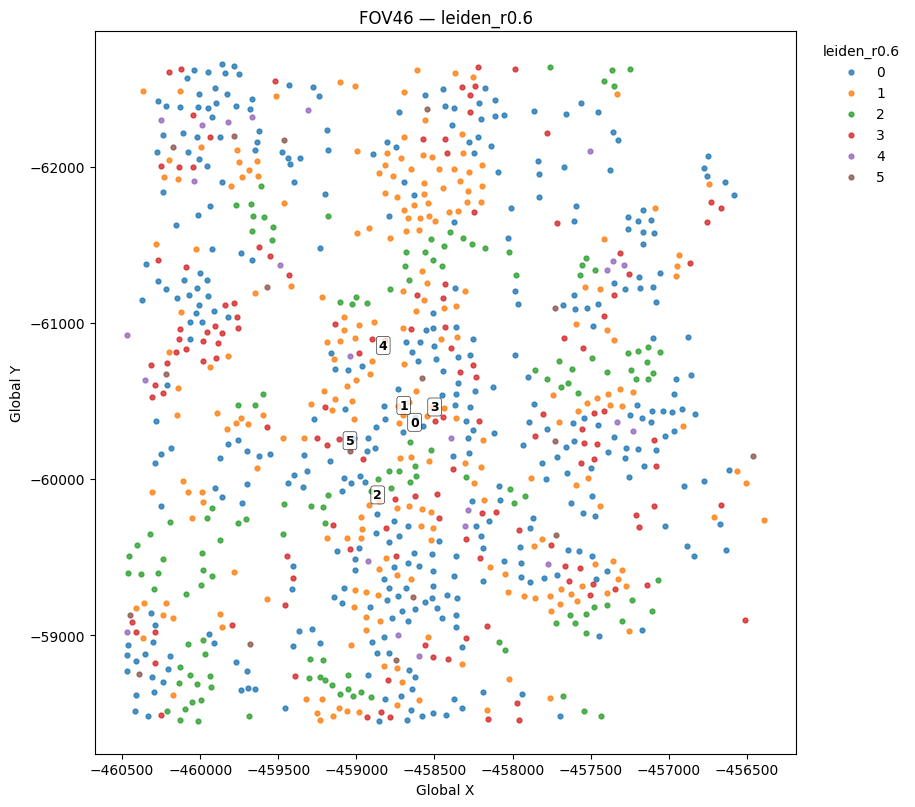

In [18]:
# Spatial map of the currently inspected resolution, with cluster labels.
xy = np.asarray(b.obsm["spatial"])
labels = b.obs[key].astype("category")

fig, ax = plt.subplots(figsize=(9, 9))
for cat in labels.cat.categories:
    m = labels.astype(str).to_numpy() == str(cat)
    x = xy[m, 0]
    y = xy[m, 1]
    ax.scatter(x, y, s=12, label=str(cat), alpha=.8)
    if len(x):
        ax.text(
            np.median(x), np.median(y), str(cat),
            fontsize=9, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor="black", alpha=.8, linewidth=.5),
            zorder=10,
        )

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_xlabel("Global X")
ax.set_ylabel("Global Y")
ax.set_title(f"FOV46 — {key}")
ax.legend(title=key, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# Versioned Leiden output configuration — EDIT HERE
# ============================================================
SAVE_SWEEP = False

LEIDEN_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "leiden_variants" / LEIDEN_TAG
LEIDEN_OUTPUT_FILE = LEIDEN_OUTPUT_DIR / f"GSM9046088_FOV46_leiden_sweep_{LEIDEN_TAG}.h5ad"
LEIDEN_SUMMARY_FILE = LEIDEN_OUTPUT_DIR / f"leiden_resolution_sweep_{LEIDEN_TAG}.csv"
LEIDEN_PARAMS_FILE = LEIDEN_OUTPUT_DIR / f"leiden_parameters_{LEIDEN_TAG}.json"

LEIDEN_PARAMS = {
    "qc_tag": QC_TAG,
    "leiden_tag": LEIDEN_TAG,
    "n_pcs_requested": N_PCS,
    "n_pcs_used": int(npcs),
    "n_neighbors": N_NEIGHBORS,
    "seed": SEED,
    "resolutions": [float(x) for x in RESOLUTIONS],
}

print("=" * 70)
print("LEIDEN OUTPUT PLAN")
print("=" * 70)
print("SAVE_SWEEP       :", SAVE_SWEEP)
print("QC_TAG           :", QC_TAG)
print("LEIDEN_TAG       :", LEIDEN_TAG)
print("Output directory :", LEIDEN_OUTPUT_DIR)
print("Output filename  :", LEIDEN_OUTPUT_FILE.name)
print("Full output path :", LEIDEN_OUTPUT_FILE)
print("Currently exists :", LEIDEN_OUTPUT_FILE.exists())


LEIDEN OUTPUT PLAN
SAVE_SWEEP       : False
QC_TAG           : mad3_interactive
LEIDEN_TAG       : mad3_interactive_pcs30_nn15
Output directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/leiden_variants/mad3_interactive_pcs30_nn15
Output filename  : GSM9046088_FOV46_leiden_sweep_mad3_interactive_pcs30_nn15.h5ad
Full output path : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/leiden_variants/mad3_interactive_pcs30_nn15/GSM9046088_FOV46_leiden_sweep_mad3_interactive_pcs30_nn15.h5ad
Currently exists : False


In [20]:
# Save only after you are satisfied with the interactive Leiden sweep.
# IMPORTANT: Python booleans are True / False, not TRUE / FALSE.
if SAVE_SWEEP:
    LEIDEN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    b.write_h5ad(LEIDEN_OUTPUT_FILE, compression="gzip")
    summary.to_csv(LEIDEN_SUMMARY_FILE, index=False)
    LEIDEN_PARAMS_FILE.write_text(json.dumps(LEIDEN_PARAMS, indent=2))
    print("Saved AnnData   :", LEIDEN_OUTPUT_FILE)
    print("Saved summary   :", LEIDEN_SUMMARY_FILE)
    print("Saved parameters:", LEIDEN_PARAMS_FILE)
else:
    print("SAVE_SWEEP=False — b remains in memory only.")


SAVE_SWEEP=False — b remains in memory only.


In [21]:
# Verify planned/saved outputs.
print("Planned AnnData:", LEIDEN_OUTPUT_FILE)
print("Exists         :", LEIDEN_OUTPUT_FILE.exists())

if LEIDEN_OUTPUT_FILE.exists():
    print(f"Size           : {LEIDEN_OUTPUT_FILE.stat().st_size / 1024**2:.2f} MB")
    print("Directory contents:")
    for path in sorted(LEIDEN_OUTPUT_DIR.glob("*")):
        print("  ", path.name)

    # Optional reload test.
    b_test = sc.read_h5ad(LEIDEN_OUTPUT_FILE)
    print("\nReload test successful:", b_test)
    print("Leiden columns:", [c for c in b_test.obs if c.startswith("leiden_r")])


Planned AnnData: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/leiden_variants/mad3_interactive_pcs30_nn15/GSM9046088_FOV46_leiden_sweep_mad3_interactive_pcs30_nn15.h5ad
Exists         : False
